# 05 - Final Comparison & Error Analysis
## Rossmann Store Sales Forecasting
Final comparison across all approaches, using the corrected (recursive) XGBoost result as the honest final number - not the naive in-test-lag version, which was a documented and fixed methodological mistake (see notebook 04, sections 5-5b).

**Final validated comparison:**
| **Model** | **Scope** | **MAE** | **RMSE** | **MAPE** | **Valid for 6-week horizon?** |
| --- | --- | --- | --- | --- | --- |
| Seasonal naive (lag-7) | Full test set | 2178.00 | 2809.07 | Yes |
| Season naive (lag-7) | 20 store subset | 2100.33 | 2615.50 | 28.57% | Yes |
| Prophet | 20 store subset | 1730.99 | 2475.17 | 22.58% | Yes |
| XGBoost | Full test set | 582.72 | 863.01 | 8.64% | **No - documented mistake** |
| **XGBoost (recursive, corrected)** | **Full test set** | **588.16** | **869.11** | **8.70%** | **Yes - the real result** |

XGBoost wins decisively over both baselines and Prophet, even after the recursive correction - a geniunely strong, now full validated result.</br>
**Worth stating plainly:** Prophet was only evaluated on a 20-store sample, never at full scale - a real limitation on how directly if can be compared to XGBoost's full set number. Extending Prophet to all 1,115 stores would require fitting 1,115 separated models (vs. XGBoost's single model covering every store at once); a real scalability difference between the two approaches worth naming explicitly, not just a fairness caveat.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path("..") / "src"))
from eval_utils import load_results

sns.set_style("whitegrid")

## 1. Full results table

In [3]:
results_df = pd.DataFrame(load_results()).T
results_df.sort_values("mae")

,mae,rmse,mape
"XGBoost, 20-store subset:",540.92,718.30,7.55
"XGBoost, full test set",582.72,863.01,8.64
"Prophet, 20-store subset",1730.99,2475.17,22.58
"Seasonal naive (lag-7), 20-store subset",2100.33,2615.50,28.57
Naive (lag-1),2119.17,3756.85,30.18
Seasonal naive (lag-7),2178.00,2809.07,31.82
Moving average (28-day),2772.20,3852.91,39.04
Moving average (7-day),2873.68,3951.02,40.80


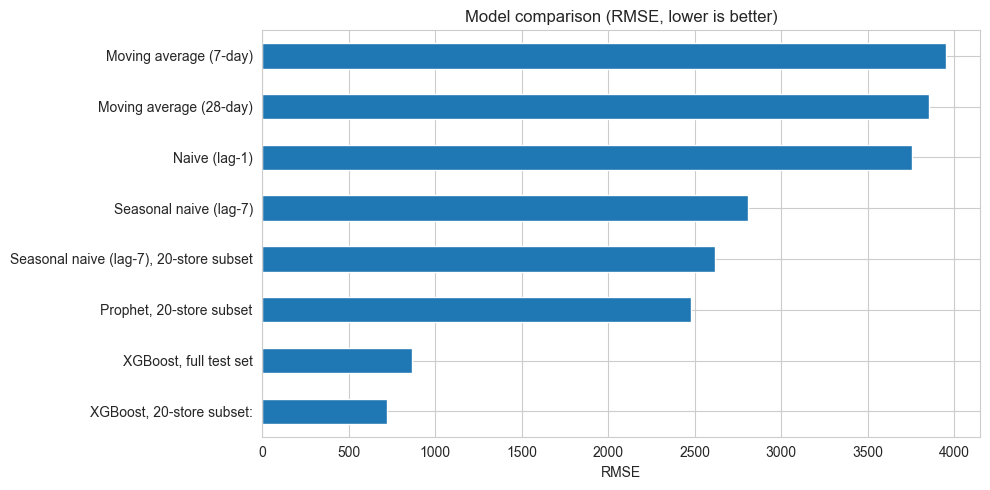

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.drop("XGBoost, naive full test set", errors="ignore")
plot_df['rmse'].sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel("RMSE")
ax.set_title("Model comparison (RMSE, lower is better)")
plt.tight_layout()
plt.show()

## 2. Revisit the hardest-to-forecast stores under the corrected model
Notebook 04 found StoreType A / Assortment C stores were hardest for the naive XGBoost evaluation. Worth checking whether that finding holds under the corrected recursive predictions, or whether it was itself partly an artifact of the leakage.

In [5]:
recursive_results = pd.read_csv("../data/processed/recursive_predictions.csv", parse_dates=['Date'])
print(f'Loaded {len(recursive_results):,} recursive predictions')
recursive_results.head()

Loaded 40,100 recursive predictions


,Store,Date,Sales,recursive_pred,days_into_horizon,horizon_bucket,StoreType,Assortment
0,1,2015-06-19,4202,4767.0474,1,1-7,c,a
1,2,2015-06-19,4926,4900.3667,1,1-7,a,a
2,3,2015-06-19,8074,7957.8600,1,1-7,a,a
3,4,2015-06-19,9686,9617.1770,1,1-7,c,c
4,5,2015-06-19,5711,5074.3726,1,1-7,a,a


In [12]:
CATEGORICAL_COLS = [
    'Store', 'StoreType', 'Assortment', 'StateHoliday']

def prepare(df):
    df = df.dropna(subset=['Sales_lag_28', 'Sales_rolling_mean_28']).copy()
    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype('category')
    return df
train_df = pd.read_csv('../data/processed/train.csv', parse_dates=['Date'])
test_df = pd.read_csv('../data/processed/test.csv', parse_dates=['Date'])
test_prepared = prepare(test_df)

In [8]:
recursive_results['abs_error'] = (recursive_results['recursive_pred'] - recursive_results['Sales']).abs()
recursive_store_errors = recursive_results.groupby('Store')['abs_error'].mean().sort_values(ascending=False)

print('Hardest stores under recursive (corrected) forecasting:')
print(recursive_store_errors.head(10))

hardest_recursive = recursive_store_errors.head(20).index
hardest_info = test_prepared[test_prepared['Store'].isin(hardest_recursive)][
    ['Store', 'StoreType', 'Assortment']
].drop_duplicates()

print('\nStoreType breakdown:')
print(hardest_info['StoreType'].value_counts())
print('\nAssortment breakdown:')
print(hardest_info['Assortment'].value_counts())

Hardest stores under recursive (corrected) forecasting:
Store
909     6608.406913
876     4025.169968
292     3010.043632
842     2042.161135
1114    1723.416000
756     1635.156500
183     1543.884827
1014    1420.397175
279     1390.823543
595     1389.411459
Name: abs_error, dtype: float64

StoreType breakdown:
StoreType
a    14
d     5
c     1
b     0
Name: count, dtype: int64

Assortment breakdown:
Assortment
c    13
a     7
b     0
Name: count, dtype: int64


In [10]:
#what's going on with store 909?
store_909 = recursive_results[recursive_results['Store'] == 909].sort_values('Date')
print(store_909[['Date', 'Sales', 'recursive_pred', 'abs_error']])

            Date  Sales  recursive_pred  abs_error
879   2015-06-19  11856       12895.623   1039.623
1937  2015-06-20  22882        9336.380  13545.620
3054  2015-06-22  41551        9802.181  31748.819
4140  2015-06-23  30038       13353.684  16684.316
5198  2015-06-24  18306       12868.894   5437.106
6284  2015-06-25  12241       10991.156   1249.844
7371  2015-06-26   9447       10309.491    862.491
8458  2015-06-27   6990        9909.801   2919.801
9575  2015-06-29   6125       16874.190  10749.190
10634 2015-06-30  10681       16103.603   5422.603
11721 2015-07-01   3547       12953.373   9406.373
27953 2015-07-18  16051       10029.180   6021.820
29069 2015-07-20  23081        7088.495  15992.505
30154 2015-07-21  16338       14645.621   1692.379
31211 2015-07-22  14708       12711.731   1996.269
32296 2015-07-23  15484       11114.340   4369.660
33381 2015-07-24  14406       11514.077   2891.923
34466 2015-07-25  14613        8793.720   5819.280
35581 2015-07-27  15236       1

In [11]:
#did something happen on those high error days?
print(test_df[(test_df['Store'] == 909) & 
    (test_df['Date'].between('2015-06-18', '2015-06-23'))][
      ['Date', 'Sales', 'Promo', 'StateHoliday', 'SchoolHoliday']
    ])

            Date  Sales  Promo  StateHoliday  SchoolHoliday
33715 2015-06-19  11856      1             0              0
33716 2015-06-20  22882      0             0              0
33717 2015-06-22  41551      0             0              0
33718 2015-06-23  30038      0             0              0


In [15]:
#does store 909 show elevated sales 2-3 after promos historically, in the training data?
store_909_train = train_df[train_df['Store'] == 909].sort_values('Date').copy()
store_909_train['days_since_promo'] = store_909_train['Promo'].replace(0, np.nan)
#quick approximation: look at sales on Monday following each Friday promo
fridays_with_promo = store_909_train[(store_909_train['Date'].dt.dayofweek == 4) & 
        (store_909_train['Promo'] == 1)]
print(f"Fridays with promo in this store's training history: {len(fridays_with_promo)}")

Fridays with promo in this store's training history: 49


In [16]:
# Check the RAW (unfiltered) data - was this store open on a normally-closed Sunday?
raw_check = pd.read_csv("../data/raw/train.csv", low_memory=False)
raw_check["Date"] = pd.to_datetime(raw_check["Date"])
print(raw_check[(raw_check["Store"] == 909) & (raw_check["Date"] == "2015-06-21")][["Date", "Open", "Sales"]])

            Date  Open  Sales
45508 2015-06-21     0      0


In [18]:
fridays_with_promo = store_909_train[
    (store_909_train["Date"].dt.dayofweek == 4) & (store_909_train["Promo"] == 1)
]["Date"]


following_mondays = fridays_with_promo + pd.Timedelta(days=3)
mondays_sales_after_promo = store_909_train[store_909_train['Date'].isin(following_mondays)]['Sales']

typical_monday_sales = store_909_train[store_909_train['Date'].dt.dayofweek == 0]['Sales']

print('Typical Monday sales for this store:')
print(typical_monday_sales.describe())
print('\nMonday sales specifically following a Friday promo:')
print(mondays_sales_after_promo.describe())

Typical Monday sales for this store:
count       95.000000
mean     12421.410526
std       3413.972954
min       7452.000000
25%       8890.500000
50%      13057.000000
75%      15655.500000
max      19501.000000
Name: Sales, dtype: float64

Monday sales specifically following a Friday promo:
count       46.000000
mean      9552.021739
std       2249.254400
min       7452.000000
25%       8225.750000
50%       8845.000000
75%       9531.750000
max      16222.000000
Name: Sales, dtype: float64


In [19]:
print(store_909_train['Sales'].describe())

count      584.000000
mean     10534.972603
std       2751.019177
min       5402.000000
25%       8209.250000
50%       9796.000000
75%      12316.500000
max      21082.000000
Name: Sales, dtype: float64


Similar to the pattern observed before, StoreType A/ Assortment C stores are geniunely harder for the model to forecast for. Store 909 has an extremely high absolute error value (6608), so I've inspected it above and I spotted two days were the forecast is way lower than the actual sales from those days: June 20th and June 22st have absolute errors of 13545 and 31748 respectively. Which points to some one-off event the model couldn't have know about. After more investigating, there was a promo day on the 19th of June; and it seems as if sales go down after a promo days (esp. if the promo day was a Friday and we are looking at Monday's sales). The skipe in sales remans unexplained by any feature available in the model, consistent with a genuine one-off event (e.g' a local occurrence, a viral moment, or possibly a data entry anomaly) rather than a systematic pattern the model failed to learn.

## 3. Visualize the recursive forecast's drift over the horizon
Same example store used through (195) - this time showing how the recursive forecast's accuracy holds up (or doesn't) as it moves from the last real data point

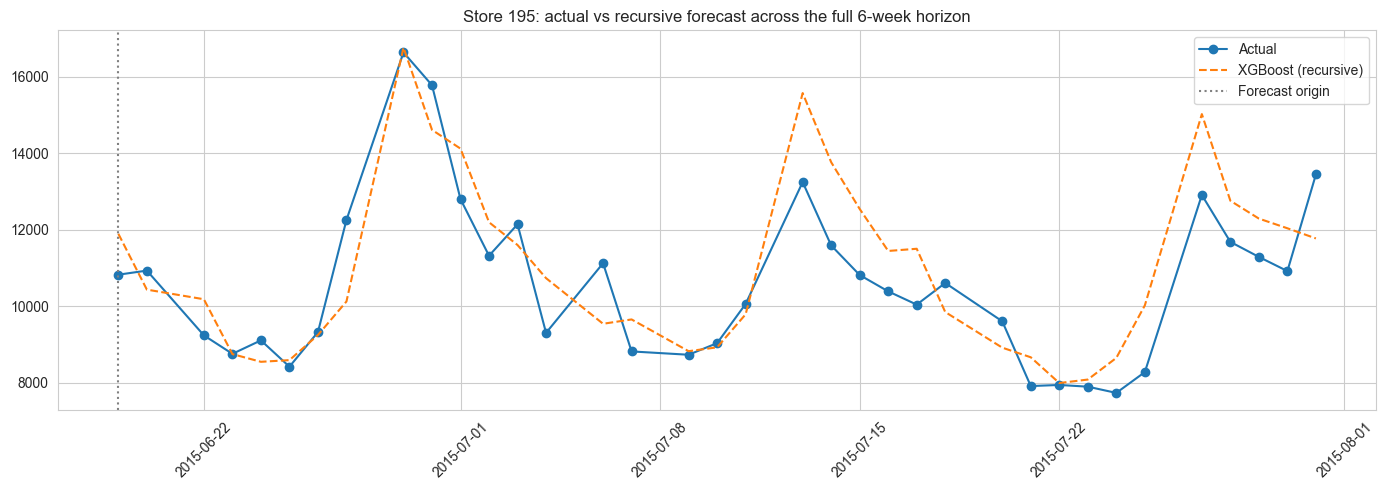

In [9]:
example_store_id = 195
example_recursive = recursive_results[recursive_results['Store'] == example_store_id].sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(example_recursive['Date'], example_recursive['Sales'], label='Actual', marker='o')
ax.plot(example_recursive['Date'], example_recursive['recursive_pred'], label='XGBoost (recursive)', linestyle='--')
ax.axvline(example_recursive['Date'].min(), color='gray', linestyle=':', label='Forecast origin')
ax.set_title(f'Store {example_store_id}: actual vs recursive forecast across the full 6-week horizon')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The forecast doesn't visibly drift far away from the actual sales later in the horizon; as time goes on, the model seems to start to consistently over predict sales, which suggests some systematic bias from the model rather than a compounding variance (where the predictions get progressively less reliable).

## 4. A production consideration: daily-refreshing forecasting
The recursive evaluation above deliberately tests the **worst case**: a single 6-week forecast predicted once, with no updates as real data comes in. In practice, most production forecasting systems refresh daily - each morning, yesterday's *real* sales becomes available, and the model re-forecasts with one more day of geniune (not predicted) history.</br>
Under that more realistic operating pattern, near-term predictions would look like the ORIGINAL "naive" numbers (582.72 MAE) - since lag-1 would almost always be geniune, not predicted while only the small number of far-horizon reports (e.g. "what do we expect sales to look like in 5 weeks") would need the recursive approach and its slightly wider error margin.</br>
Given how close the naive (582.72) and recursive (588.16) numbers turned out to be, this suggests the choice between these two deployment patterns doesn't matters much for this specific model - a nice, concrete conclusion enabled directly by having done the recursive correction in the first place.

## 5. Final model choice
**XGBoost (recursive-corrected), trained on the full dataset.** Beats every baseline and beats Prophet on the comparable subset, by a wide and now full validated marging. </br>
**Deployment consideration worth flagging explicitly:** unlike Projects 1 and 2, where the deployed API took a single, self-contained row of input features, this model depends on each store's recent sales history to compute lag/rolling features. A real API needs of: </br>
* The caller supplies recent history as part of the request, or
* The server maintains/bundles a small reference table of recent sales per store (practical for a portfolio demo; would need a real data pipeline in production to stay current)
This is a different deployment shape than the previous two projects, and worth designing deliberately rather than assuming the same pattern will work.

## 6. Summary
**Final validated comparison:**

| Model | Scope | MAE | RMSE | MAPE |
|---|---|---|---|---|
| Seasonal naive (lag-7) | Full test set | 2178.00 | 2809.07 | 31.82% | 
| Seasonal naive (lag-7) | 20-store subset | 2100.33 | 2615.50 | 28.57% |
| Prophet | 20-store subset | 1730.99 | 2475.17 | 22.58% | Yes |
| XGBoost (naive, in-test lags) | Full test set | 582.72 | 863.01 | 8.64% |
| **XGBoost (recursive, corrected)** | **Full test set** | **588.16** | **869.11** | **8.70%** | 

The hardest-stores to forecast for are StoreType A and Assortment C, with Store 909 having a one-off event the model couldn't have know about (a very high absolute error on June 21st of over 30000). Visualizing the comparison of the model's prediction and the actual sales shows over time the model will consistently over predict sales (systematic bias).